#Parte 1

##Busca Clássica


In [ ]:
#Algoritmo de busca básico, que retorna a quantidade de contagens realizadas
def busca(lista:list,alvo) -> int:
  contagem = 0;
  for i in range(len(lista)):
    contagem += 1
    if lista[i] == alvo:
      return contagem




In [ ]:
#Simulação

lista = [0, 1, 2, 3]

# Dicionário
resultados = {}

# Executa a busca para cada cenário possível
for item_marcado in lista:
    consultas = busca(lista,item_marcado)
    resultados[item_marcado] = consultas
    print(f"Item na posição {item_marcado} -> Consultas: {consultas}")

media = sum(resultados.values()) / len(resultados)
pior_caso = max(resultados.values())
print()
print(f"Pior caso de consultas: {pior_caso}")
print(f"Média de consultas: {media}")

Item na posição 0 -> Consultas: 1
Item na posição 1 -> Consultas: 2
Item na posição 2 -> Consultas: 3
Item na posição 3 -> Consultas: 4

Pior caso de consultas: 4
Média de consultas: 2.5


Com base no código acima, podemos perceber que atingimos os resultados esperados:
*  pior caso é termos que iterar 4 vezes
* média de consultas acaba sendo 2,5

#Parte 2

instalando o que vamos usar...

In [ ]:
!pip install qiskit
!pip install pylatexenc



In [ ]:
!pip install qiskit-aer

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

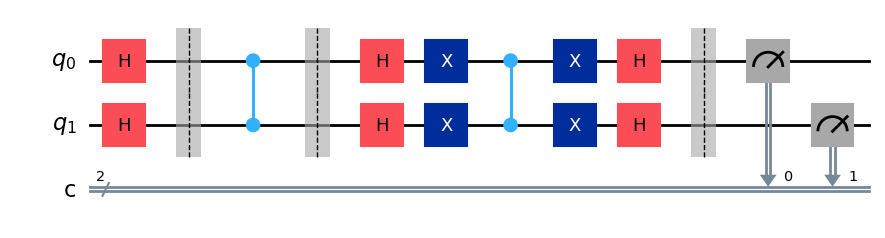

In [ ]:
# Criação de um circuito com 2 qubits e 2 bits clássicos
circuito_de_grover = QuantumCircuit(2, 2)

# (a) Inicialização - Superposição Uniforme
# Aplica a porta Hadamard em ambos os qubits
circuito_de_grover.h(0)
circuito_de_grover.h(1)

circuito_de_grover.barrier() # Barreira apenas para organizar visualmente o circuito

# (b) Oráculo (Para o estado 11)
# Uma porta CZ inverte o sinal apenas do estado |11>
circuito_de_grover.cz(0, 1)

circuito_de_grover.barrier()

# (c) Operador de Difusão (Inversão sobre a média)
# Sequência dada: H -> X -> CZ -> X -> H
circuito_de_grover.h(0)
circuito_de_grover.h(1)

circuito_de_grover.x(0)
circuito_de_grover.x(1)

circuito_de_grover.cz(0, 1) # CZ interna do difusor

circuito_de_grover.x(0)
circuito_de_grover.x(1)

circuito_de_grover.h(0)
circuito_de_grover.h(1)

circuito_de_grover.barrier()

# Medição final

# Mede os qubits 0 e 1 nos bits clássicos 0 e 1
circuito_de_grover.measure([0, 1], [0, 1])

# Desenha o circuito para conferência visual
circuito_de_grover.draw('mpl')

Contagens: {'11': 1024}


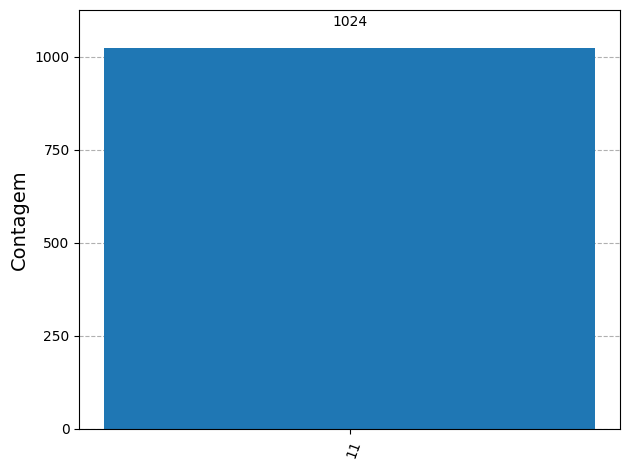

In [ ]:
# Inicializa o simulador
simulador = AerSimulator()

# Executa o circuito
job = simulador.run(circuito_de_grover, shots=1024)
resultado = job.result()

# Obtém as contagens dos estados medidos
contagens = resultado.get_counts()
print("Contagens:", contagens)


fig = plot_histogram(contagens)
ax = fig.gca()
ax.set_ylabel('Contagem')
fig

#Parte 3

##  Parte 3 - Análise Comparativa

Esta seção apresenta a comparação quantitativa entre a busca linear clássica e o algoritmo quântico de Grover para um cenário com $N=4$ elementos. Conforme os requisitos do projeto, os dados consolidados, o histograma de medições e a análise teórica estão documentados conjuntamente a seguir.

### Tabela Comparativa de Consultas

A comparação abaixo utiliza como critério o número de consultas feitas à função de busca $f(x)$ para encontrar o item marcado:

| Abordagem | Consultas $(N=4)$ |
| :--- | :--- |
| Clássica caso médio | 2,5 |
| Clássica pior caso | 4 |
| Grover | 1 |

Histograma de medições obtido via AerSimulator (1024 shots):


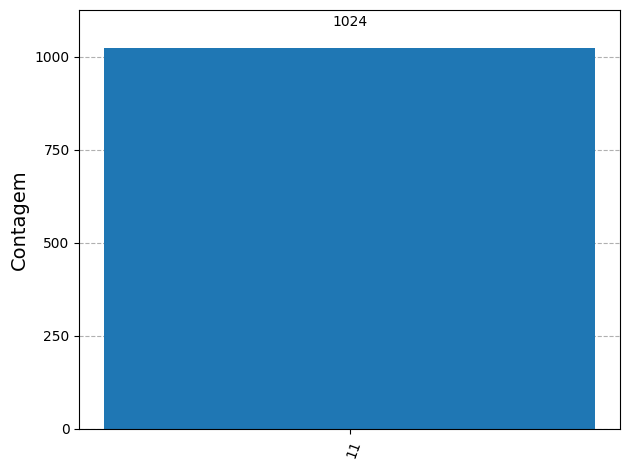

In [ ]:

print("Histograma de medições obtido via AerSimulator (1024 shots):")
fig

### Discussão dos Resultados e Análise de Métrica

O algoritmo de Grover demonstrou eficiência máxima, encontrando o item marcado com probabilidade 1 utilizando apenas 1 consulta ao oráculo, superando tanto o caso médio (2,5 consultas) quanto o pior caso (4 consultas) da busca linear clássica.

E necessario compreender por que a comparação deve ser feita estritamente pelo **número de consultas à função de busca**, e não pelo tempo de execução em segundo. Os motivos fundamentais são:

 * **Independência de Hardware**: O tempo de execução varia conforme o processador, sistema operacional e linguagem utilizada. O número de consultas é uma métrica matemática pura, universal e invariável.  
* **Simulação vs. Hardware Quântico**: O circuito foi executado no AerSimulator (um computador clássico simulando física quântica). O tempo bruto de simulação é alto devido ao cálculo de matrizes complexas, o que mascararia a real aceleração de um chip quântico nativo.
* **Foco no Custo do Oráculo**: A função $f(x)$ atua como uma caixa-preta que, em problemas reais, representa a operação mais pesada do sistema. Contar as consultas avalia o algoritmo diretamente pelo seu recurso mais caro e limitante.

###OBS :
 Na computação quântica, nós não passamos uma lista clássica (como um array ) para dentro do circuito.

 Não existe um comando como circuito.buscar(lista).

 A "lista" é representada de forma implícita pelo espaço de estados dos qubits.

 Como o  problema tinha uma lista de 4 elementos, foram utilizados 2 qubits.2 qubits em superposição conseguem representar exatamente $2^2 = 4$ estados simultaneamente: |00>, |01>, |10> e |11>.

 No meu código eu configurei para procurar o número 3 que seria |11> e sempre o número de consultas retornou 1.


Para testar outras soluções você pode testar as células abaixo

Resultado da busca pelo Elemento 0: {'00': 1000}


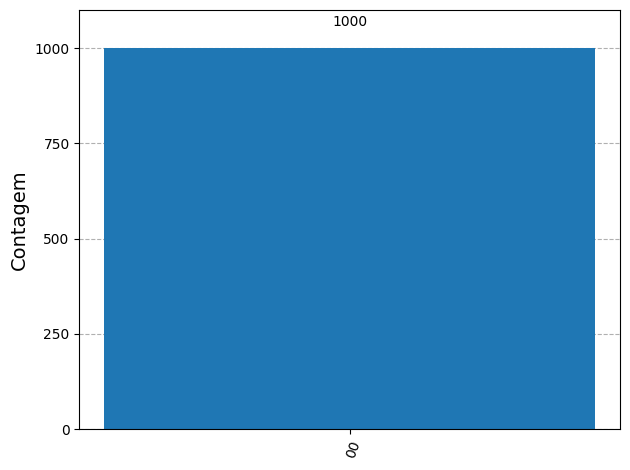

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# 1. Inicialização do Circuito (2 qubits e 2 bits clássicos)
qc_0 = QuantumCircuit(2, 2)
qc_0.h([0, 1])  # Coloca em superposição (cria a "lista" de 4 elementos)

# 2. ORÁCULO para o Elemento 0 (|00>)
qc_0.x([0, 1])  # Inverte ambos porque ambos são '0' no alvo
qc_0.cz(0, 1)   # Aplica a marcação de fase
qc_0.x([0, 1])  # Desfaz a inversão

# 3. DIFUSOR (Inversão sobre a média)
qc_0.h([0, 1])
qc_0.x([0, 1])
qc_0.cz(0, 1)
qc_0.x([0, 1])
qc_0.h([0, 1])

# 4. MEDIÇÃO
qc_0.measure([0, 1], [0, 1])

# 5. EXECUÇÃO
simulador = AerSimulator()
resultado = simulador.run(qc_0, shots=1000).result()
contagem = resultado.get_counts()

print("Resultado da busca pelo Elemento 0:", contagem)

fig = plot_histogram(contagem)
ax = fig.gca()
ax.set_ylabel('Contagem')
display(fig)

Resultado da busca pelo Elemento 1: {'01': 1000}


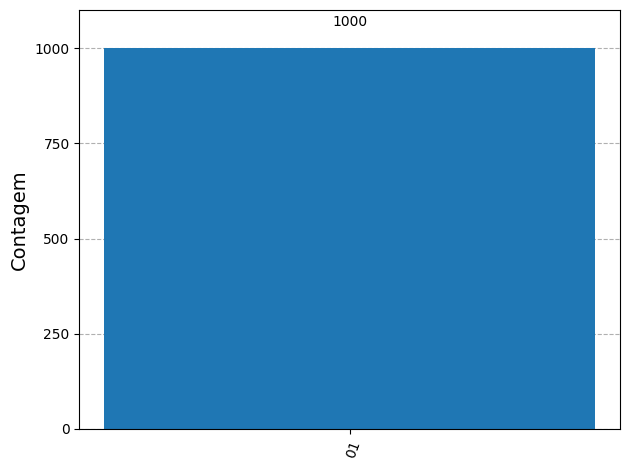

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# 1. Inicialização do Circuito
qc_1 = QuantumCircuit(2, 2)
qc_1.h([0, 1])

# 2. ORÁCULO para o Elemento 1 (|01>)
qc_1.x(1)     # Inverte apenas o qubit 1 (que vale '0' no alvo)
qc_1.cz(0, 1) # Aplica a marcação de fase
qc_1.x(1)     # Desfaz a inversão

# 3. DIFUSOR
qc_1.h([0, 1])
qc_1.x([0, 1])
qc_1.cz(0, 1)
qc_1.x([0, 1])
qc_1.h([0, 1])

# 4. MEDIÇÃO
qc_1.measure([0, 1], [0, 1])

# 5. EXECUÇÃO
simulador = AerSimulator()
resultado = simulador.run(qc_1, shots=1000).result()
contagem = resultado.get_counts()
print("Resultado da busca pelo Elemento 1:", contagem)

fig = plot_histogram(contagem)
ax = fig.gca()
ax.set_ylabel('Contagem')
display(fig)

Resultado da busca pelo Elemento 2: {'10': 1000}


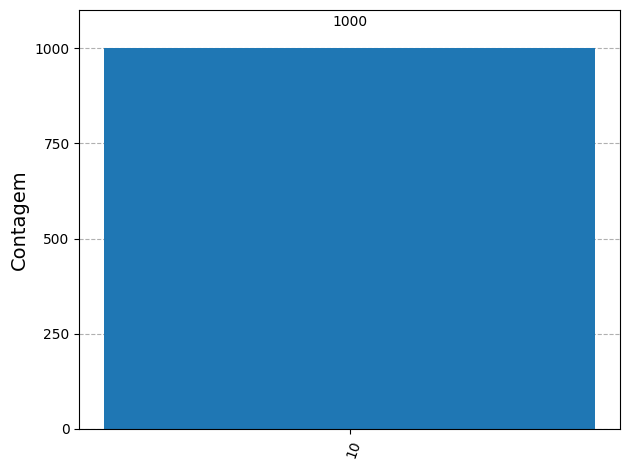

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# 1. Inicialização do Circuito
qc_2 = QuantumCircuit(2, 2)
qc_2.h([0, 1])

# 2. ORÁCULO para o Elemento 2 (|10>)
qc_2.x(0)     # Inverte apenas o qubit 0 (que vale '0' no alvo)
qc_2.cz(0, 1) # Aplica a marcação de fase
qc_2.x(0)     # Desfaz a inversão

# 3. DIFUSOR
qc_2.h([0, 1])
qc_2.x([0, 1])
qc_2.cz(0, 1)
qc_2.x([0, 1])
qc_2.h([0, 1])

# 4. MEDIÇÃO
qc_2.measure([0, 1], [0, 1])

# 5. EXECUÇÃO
simulador = AerSimulator()
resultado = simulador.run(qc_2, shots=1000).result()
contagem = resultado.get_counts()
print("Resultado da busca pelo Elemento 2:", contagem)

fig = plot_histogram(contagem)
ax = fig.gca()
ax.set_ylabel('Contagem')
display(fig)

Resultado da busca pelo Elemento 3: {'11': 1000}


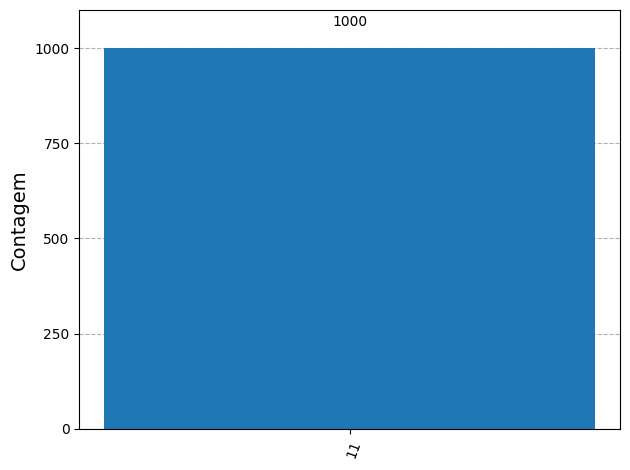

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# 1. Inicialização do Circuito
qc_3 = QuantumCircuit(2, 2)
qc_3.h([0, 1])

# 2. ORÁCULO para o Elemento 3 (|11>)
qc_3.cz(0, 1) # A porta CZ já atua diretamente quando ambos são '1'

# 3. DIFUSOR
qc_3.h([0, 1])
qc_3.x([0, 1])
qc_3.cz(0, 1)
qc_3.x([0, 1])
qc_3.h([0, 1])

# 4. MEDIÇÃO
qc_3.measure([0, 1], [0, 1])

# 5. EXECUÇÃO
simulador = AerSimulator()
resultado = simulador.run(qc_3, shots=1000).result()
contagem = resultado.get_counts()
print("Resultado da busca pelo Elemento 3:", contagem)

fig = plot_histogram(contagem)
ax = fig.gca()
ax.set_ylabel('Contagem')
display(fig)